# Diffusion models in AI as statistical physics: a minimal 1D example

This notebook gives a **hands-on**, self-contained bridge between:

- **Real diffusion in statistical physics** (Langevin dynamics, Fokker–Planck / heat equation)
- **Diffusion models in AI** (DDPM / score-based generative modeling)

We will work in **1D** so everything is transparent and fast.

---

## Roadmap

1. Diffusion in physics: Brownian motion, heat equation, Fokker–Planck  
2. The *forward* noising process used in diffusion models  
3. Scores: the key object $\nabla_x \log p_t(x)$  
4. Reverse-time dynamics: generating data by running a stochastic process *backwards*  
5. A concrete demo: generate a **mixture of Gaussians** without training a neural net (we use the *exact* score)


## 1) Diffusion in statistical physics (one page)

A standard overdamped Langevin model for a particle in a potential $U(x)$ at temperature $T$ is

\[
\dot x = -\mu\,\partial_x U(x) + \sqrt{2D}\,\eta(t), \qquad \langle \eta(t)\eta(t')\rangle = \delta(t-t')
\]

with mobility $\mu$ and diffusion constant $D = \mu k_B T$ (Einstein relation).

The probability density $p(x,t)$ evolves by the **Fokker–Planck equation**

\[
\partial_t p = -\partial_x\!\left( (-\mu U'(x))\,p \right) + D\,\partial_x^2 p .
\]

Special case $U(x)=0$ gives the **heat equation** $\partial_t p = D\partial_x^2 p$: diffusion in its purest form.

---

### Diffusion models in AI: same math, different goal

Diffusion models define a **forward** process that gradually destroys structure in data until it becomes an easy
reference distribution (typically Gaussian). Then they learn (or otherwise obtain) the **reverse** process that
turns Gaussian noise back into samples from the data distribution.

In physics terms: we can view the forward process as a *stochastic dynamics* that increases entropy,
and the reverse process as a controlled dynamics that *undoes* it using a learned force field (a score).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130


## 2) A simple "dataset": a 1D mixture of Gaussians

We'll use a bimodal target distribution

\[
p_0(x) = \tfrac12 \mathcal N(x;\,-m,\sigma_0^2) + \tfrac12 \mathcal N(x;\,+m,\sigma_0^2).
\]

This is simple enough that we can compute the *exact* score $\partial_x \log p_t(x)$ after noising,
so we can demonstrate the whole diffusion-model idea **without training**.


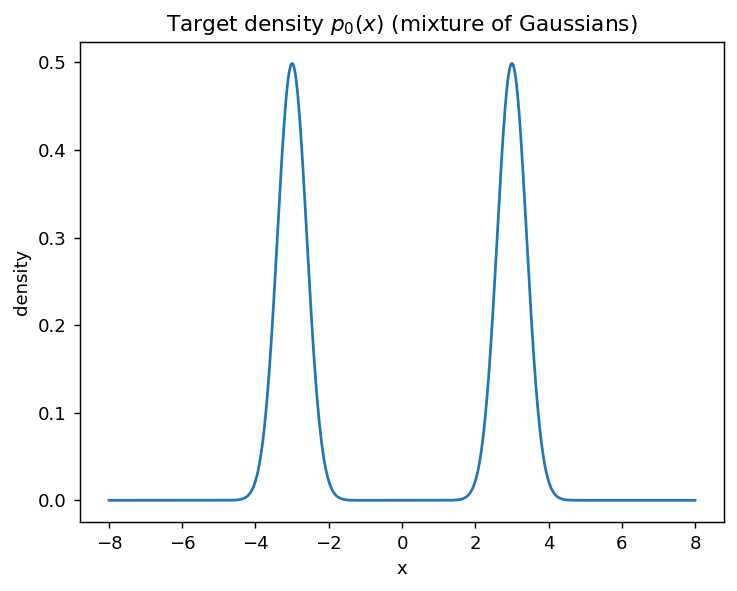

In [2]:
# Target distribution parameters
m = 3.0
sigma0 = 0.4

def normal_pdf(x, mu, sig):
    return np.exp(-0.5*((x-mu)/sig)**2) / (np.sqrt(2*np.pi)*sig)

def p0(x):
    return 0.5*normal_pdf(x, -m, sigma0) + 0.5*normal_pdf(x, +m, sigma0)

# sample from p0
rng = np.random.default_rng(0)
def sample_p0(n):
    signs = rng.choice([-1.0, +1.0], size=n)
    return signs*m + sigma0*rng.standard_normal(n)

# quick visualization
xs = np.linspace(-8, 8, 1200)
plt.figure()
plt.plot(xs, p0(xs))
plt.title("Target density $p_0(x)$ (mixture of Gaussians)")
plt.xlabel("x"); plt.ylabel("density")
plt.show()


## 3) Forward diffusion (DDPM view)

A common discrete-time forward process is

\[
x_{t+1} = \sqrt{1-\beta_t}\,x_t + \sqrt{\beta_t}\,\varepsilon_t,\qquad \varepsilon_t\sim\mathcal N(0,1).
\]

After many small steps, this washes out structure and approaches a standard normal.
One can show (by iterating Gaussians) that

\[
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\quad
\bar\alpha_t=\prod_{s=1}^t (1-\beta_s).
\]

So **conditional on $x_0$**, $x_t$ is Gaussian. This is exactly like adding Brownian noise,
just written in a convenient *reparameterized* discrete form.

We'll implement a gentle noise schedule and visualize how the distribution evolves.


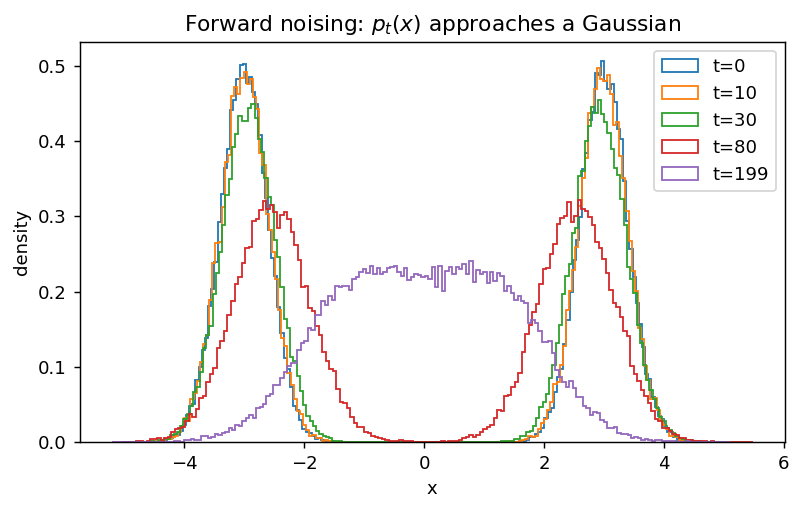

In [3]:
# Forward schedule
T = 200                      # number of diffusion steps
beta = np.linspace(1e-4, 0.02, T)          # simple linear schedule
alpha = 1.0 - beta
alpha_bar = np.cumprod(alpha)

def q_sample(x0, t, rng):
    """Sample x_t given x0 using the closed-form reparameterization."""
    ab = alpha_bar[t]
    return np.sqrt(ab)*x0 + np.sqrt(1.0-ab)*rng.standard_normal(x0.shape)

# Visualize noising: histograms at a few times
n = 60_000
x0 = sample_p0(n)

ts_show = [0, 10, 30, 80, 199]
plt.figure(figsize=(7,4))
for t in ts_show:
    xt = q_sample(x0, t, rng)
    plt.hist(xt, bins=180, density=True, histtype="step", label=f"t={t}")
plt.title("Forward noising: $p_t(x)$ approaches a Gaussian")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()


## 4) The score $\partial_x \log p_t(x)$

Score-based diffusion models revolve around the **score**

\[
s_t(x) \equiv \partial_x \log p_t(x).
\]

In physics language, if a density is Boltzmann-like $p(x)\propto e^{-\beta U(x)}$ then
$\partial_x \log p(x) = -\beta\,U'(x)$ is (minus) a force.
So learning the score is like learning an effective force field.

For our mixture-of-Gaussians target, we can write down $p_t(x)$ exactly:

Noising replaces each component variance by
\[
\sigma_t^2 = \bar\alpha_t\,\sigma_0^2 + (1-\bar\alpha_t),
\]
and shrinks the means to $\pm \sqrt{\bar\alpha_t}\,m$.

So
\[
p_t(x)=\tfrac12\mathcal N\!\left(x;\,-\sqrt{\bar\alpha_t}m,\sigma_t^2\right)+
       \tfrac12\mathcal N\!\left(x;\,+\sqrt{\bar\alpha_t}m,\sigma_t^2\right).
\]

We can compute $s_t(x)$ by differentiating $\log p_t(x)$.


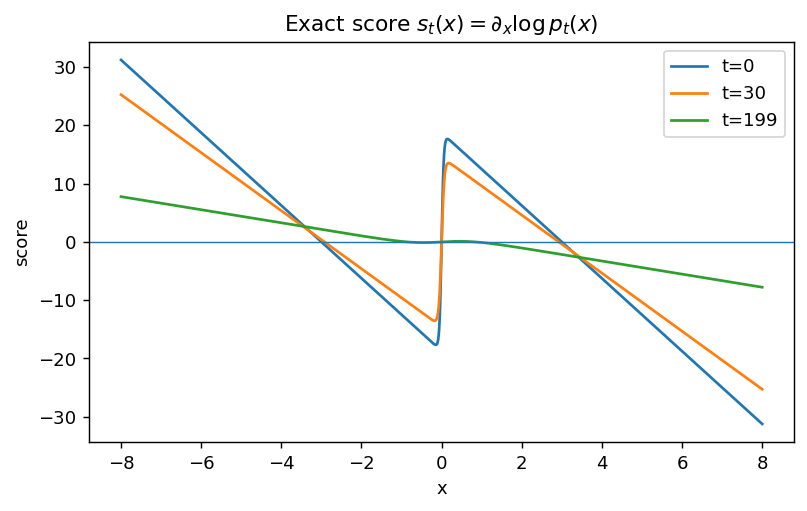

In [4]:
def pt(x, t):
    ab = alpha_bar[t]
    mu = np.sqrt(ab)*m
    sig2 = ab*(sigma0**2) + (1.0-ab)
    sig = np.sqrt(sig2)
    return 0.5*normal_pdf(x, -mu, sig) + 0.5*normal_pdf(x, +mu, sig)

def score_exact(x, t):
    """s_t(x) = d/dx log p_t(x) for the noised mixture."""
    ab = alpha_bar[t]
    mu = np.sqrt(ab)*m
    sig2 = ab*(sigma0**2) + (1.0-ab)
    sig = np.sqrt(sig2)
    # component pdfs
    pL = 0.5*normal_pdf(x, -mu, sig)
    pR = 0.5*normal_pdf(x, +mu, sig)
    p = pL + pR
    # derivative of log of a Gaussian: d/dx log N(x;mu,sig^2)=-(x-mu)/sig^2
    dlogL = -(x + mu)/sig2
    dlogR = -(x - mu)/sig2
    return (pL*dlogL + pR*dlogR) / np.maximum(p, 1e-300)

# visualize score at a couple times
xs = np.linspace(-8, 8, 1200)
plt.figure(figsize=(7,4))
for t in [0, 30, 199]:
    plt.plot(xs, score_exact(xs, t), label=f"t={t}")
plt.axhline(0, linewidth=0.8)
plt.title("Exact score $s_t(x)=\partial_x\log p_t(x)$")
plt.xlabel("x"); plt.ylabel("score")
plt.legend()
plt.show()


## 5) Reverse-time dynamics (how generation works)

There are two popular but related views:

### (a) Discrete DDPM sampler
A learned model predicts the noise (or $x_0$) at each step and constructs
a Gaussian transition that approximately samples $p(x_{t-1}\mid x_t)$.

### (b) Continuous score-based sampler (SDE view)
Consider the *forward* SDE
\[
dx = f(x,t)\,dt + g(t)\,dW_t.
\]
A classic result (Anderson, 1982) says that the *reverse-time* SDE is
\[
dx = \big[f(x,t) - g(t)^2\,\nabla_x \log p_t(x)\big]dt + g(t)\,d\bar W_t,
\]
where $p_t$ is the forward-time density and $\bar W_t$ is a Wiener process in reverse time.

**Key point:** the reverse drift depends on the **score**.  
So *knowing the score is enough to generate samples*.

We'll implement a simple continuous-time limit corresponding to an **Ornstein–Uhlenbeck (OU) noising process**
because it is mathematically clean and closely connected to equilibrium statistical physics.


### OU forward process (nice physics intuition)

Take the forward SDE
\[
dx = -\tfrac12 \beta(t)\,x\,dt + \sqrt{\beta(t)}\,dW_t.
\]
This is OU with time-dependent noise rate $\beta(t)$. It drives *any* initial distribution toward a standard normal.

It has the same closed form as DDPM (with a matching schedule):  
\[
x(t) = \sqrt{\bar\alpha(t)}\,x(0) + \sqrt{1-\bar\alpha(t)}\,\varepsilon.
\]

We'll now generate *new* samples by starting from $x(T)\sim\mathcal N(0,1)$ and integrating the **reverse** SDE,
using the **exact score** from above.


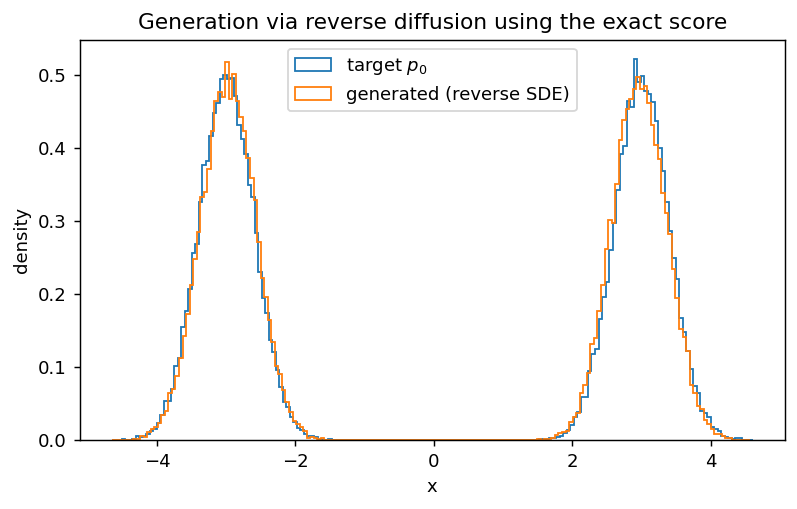

In [5]:
# Continuous-time-like reverse sampler using the discrete schedule as a time grid.
# We'll implement the reverse SDE for the OU-type forward process:
#   x_{t-1} = x_t + [0.5*beta_t*x_t + beta_t*score(x_t,t)] + sqrt(beta_t)*z
# with z ~ N(0,1). (This is an Euler-Maruyama step for reverse time.)

def reverse_sample(n, rng):
    x = rng.standard_normal(n)   # start from N(0,1) ~ p_T
    # iterate backward
    for t in reversed(range(T)):
        bt = beta[t]
        # reverse drift: +0.5*beta*x + beta*score
        drift = 0.5*bt*x + bt*score_exact(x, t)
        x = x + drift
        if t > 0:  # add noise except at the final step
            x = x + np.sqrt(bt)*rng.standard_normal(n)
    return x

# Generate samples
n_gen = 50_000
x_gen = reverse_sample(n_gen, rng)

# Compare with target
plt.figure(figsize=(7,4))
plt.hist(sample_p0(n_gen), bins=180, density=True, histtype="step", label="target $p_0$")
plt.hist(x_gen,          bins=180, density=True, histtype="step", label="generated (reverse SDE)")
plt.title("Generation via reverse diffusion using the exact score")
plt.xlabel("x"); plt.ylabel("density")
plt.legend()
plt.show()


## 6) What this teaches (stat-phys connections)

- **Forward noising** is just a stochastic dynamics that increases entropy and flows toward a simple steady state (Gaussian).
- The **score** is a gradient of log-probability; in equilibrium statistical mechanics it plays the role of a **force**.
- **Generation** is running a stochastic dynamics *backwards in time* by adding the right extra drift term (the score).

### Exercises / extensions
1. Change the target distribution (e.g., 3 modes, heavy tails) and see how noising / reverse changes.  
2. Replace the exact score by a *learned* score:
   - sample pairs $(x_t,t)$ from the forward process
   - train a small MLP to regress the noise $\varepsilon$ (DDPM objective)
   - use it in the reverse sampler above.
3. Connect to thermodynamics:
   - interpret the score term as a control force
   - discuss path probabilities and the analogy to time-reversal in nonequilibrium statistical mechanics.
